In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# para viz
import altair as alt

# desactivar vegafusion y el renderer HTML de Altair para este entorno
alt.data_transformers.enable("vegafusion")

# para el calculo del IVF
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# para el calculo del PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%pip install --upgrade pyarrow

Note: you may need to restart the kernel to use updated packages.


In [33]:
df = pd.read_csv(
    'indicadores_mensuales.csv',
    encoding='latin1',
    sep=';',
    decimal=','
)

# Traducir nombres de columnas al inglés
translation_dict = {
    'anio': 'year',
    'periodo': 'period',
    'mes': 'month',
    'area': 'area',
    'ciudad': 'city',
    'tasa_participacion_global': 'global_participation_rate',
    'tasa_participacion_bruta': 'gross_participation_rate',
    'tasa_desempleo': 'unemployment_rate',
    'empleo_total': 'total_employment',
    'empleo_formal': 'formal_employment',
    'empleo_informal': 'informal_employment',
    'empleo_adecuado': 'adequate_employment',
    'subempleo': 'underemployment',
    'no_remunerado': 'unpaid_work',
    'otro_no_pleno': 'other_non_full_employment',
    'brecha_adecuado_HM': 'adequate_employment_gap_hm',
    'brecha_salarial_HM': 'salary_gap_hm',
    'NiNi': 'neet',
    'desempleo_juvenil': 'youth_unemployment',
    'trabajo_infantil': 'child_labor',
    'empleo_manufactura': 'manufacturing_employment',
    'tasa_asistencia_clases': 'school_attendance_rate',
    'pobreza_ingresos': 'income_poverty',
    'pobreza_extrema_ingresos': 'extreme_income_poverty'
}

# Renombrar columnas que existan
for old_name, new_name in translation_dict.items():
    if old_name in df.columns:
        df = df.rename(columns={old_name: new_name})

df.columns = df.columns.str.lower()

# Tratar ciudad como cadena de caracteres
if 'city' in df.columns:
    df['city'] = df['city'].astype('Int64').astype(str).str.zfill(6)

id_str_cols = ['city', 'month']
id_int_cols = ['year', 'period', 'area']
for col in df.columns:
    if col not in id_str_cols and col not in id_int_cols:
        df[col] = df[col].astype('Float64')
    if col in id_int_cols:
        df[col] = df[col].astype('Int64')
df.head()

,year,period,month,area,city,global_participation_rate,gross_participation_rate,unemployment_rate,total_employment,formal_employment,...,other_non_full_employment,adequate_employment_gap_hm,salary_gap_hm,neet,youth_unemployment,child_labor,manufacturing_employment,school_attendance_rate,income_poverty,extreme_income_poverty
0,2007,6,Junio,1,010150,69.6709,50.6597,5.6692,94.3308,67.7679,...,14.9143,32.5062,38.3322,8.8601,8.4198,5.0324,19.5232,79.0481,12.9154,3.4991
1,2007,6,Junio,1,070150,69.5793,47.9878,6.39,93.61,44.5163,...,18.088,24.5242,19.8952,18.1669,8.9962,4.7061,8.7018,73.8733,23.7168,7.3746
2,2007,6,Junio,1,090150,70.2874,50.1103,8.9783,91.0217,53.3911,...,15.6068,32.5023,28.153,17.665,15.9064,6.1991,13.7591,75.6331,19.1637,6.132
3,2007,6,Junio,1,170150,68.7131,50.6626,5.9597,94.0403,68.125,...,14.0037,32.6926,47.4736,11.6609,9.6217,4.873,14.9477,77.9396,11.7764,3.4935
4,2007,6,Junio,1,180150,67.9143,50.2609,4.2956,95.7044,68.6879,...,16.9191,33.5418,32.4586,9.4014,8.6598,5.4683,18.4217,81.4531,14.2329,4.2952


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        835 non-null    Int64  
 1   period                      835 non-null    Int64  
 2   month                       835 non-null    str    
 3   area                        835 non-null    Int64  
 4   city                        835 non-null    str    
 5   global_participation_rate   835 non-null    Float64
 6   gross_participation_rate    835 non-null    Float64
 7   unemployment_rate           835 non-null    Float64
 8   total_employment            835 non-null    Float64
 9   formal_employment           835 non-null    Float64
 10  informal_employment         835 non-null    Float64
 11  adequate_employment         835 non-null    Float64
 12  underemployment             835 non-null    Float64
 13  unpaid_work                 835 non-null    Fl

In [36]:
df.describe()

,year,period,area,global_participation_rate,gross_participation_rate,unemployment_rate,total_employment,formal_employment,informal_employment,adequate_employment,...,other_non_full_employment,adequate_employment_gap_hm,salary_gap_hm,neet,youth_unemployment,child_labor,manufacturing_employment,school_attendance_rate,income_poverty,extreme_income_poverty
count,835.0,835.0,835.0,835.0,835.0,835.0,835.0,835.0,835.0,835.0,...,835.0,828.0,831.0,828.0,824.0,827.0,835.0,834.0,835.0,835.0
mean,2018.675449,7.037126,1.299401,66.421,49.749414,5.140647,94.859353,60.185546,32.689166,48.424601,...,23.395945,29.677616,22.437376,16.677933,10.678949,2.053821,13.906131,77.996113,12.788551,3.596361
std,5.46419,3.531946,0.45827,7.342329,6.954126,3.774066,3.774066,15.766562,14.825057,13.165283,...,9.736476,43.426929,23.886686,12.092971,9.726943,6.823578,7.326927,9.443054,10.594457,5.010565
min,2007.0,1.0,1.0,38.4615,21.2766,0.0,69.2308,0.0,0.0,0.0,...,0.0,-641.1434,-197.0297,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2014.0,4.0,1.0,62.5,46.3561,3.1732,93.1122,51.8337,22.33785,42.14425,...,17.8999,20.995425,15.48975,10.4446,6.0178,0.0,9.65825,75.193925,7.355,0.8039
50%,2021.0,6.0,1.0,65.2478,48.8146,4.6611,95.3389,63.3186,28.9503,49.4147,...,21.4286,27.9088,22.6154,15.7354,9.66995,0.4858,14.2857,79.5962,10.9077,2.4604
75%,2023.0,10.0,2.0,69.3602,51.86475,6.8878,96.8268,71.7984,39.96175,57.09925,...,25.8383,36.469375,30.18175,20.361575,13.8404,1.85515,18.39135,82.60005,16.4557,4.06515
max,2026.0,12.0,2.0,100.0,86.6667,30.7692,100.0,100.0,100.0,100.0,...,76.9231,100.0,100.0,100.0,100.0,100.0,39.5074,100.0,91.0714,50.0


In [37]:
id_cols = ['year','period','month','area', 'city']
num_cols = [c for c in df.columns if c not in id_cols]
df[num_cols].head()

,global_participation_rate,gross_participation_rate,unemployment_rate,total_employment,formal_employment,informal_employment,adequate_employment,underemployment,unpaid_work,other_non_full_employment,adequate_employment_gap_hm,salary_gap_hm,neet,youth_unemployment,child_labor,manufacturing_employment,school_attendance_rate,income_poverty,extreme_income_poverty
0,69.6709,50.6597,5.6692,94.3308,67.7679,25.9808,60.5264,13.9054,4.9847,14.9143,32.5062,38.3322,8.8601,8.4198,5.0324,19.5232,79.0481,12.9154,3.4991
1,69.5793,47.9878,6.39,93.61,44.5163,47.4584,44.3059,24.6281,5.8118,18.088,24.5242,19.8952,18.1669,8.9962,4.7061,8.7018,73.8733,23.7168,7.3746
2,70.2874,50.1103,8.9783,91.0217,53.3911,38.1355,51.0419,18.6045,5.0283,15.6068,32.5023,28.153,17.665,15.9064,6.1991,13.7591,75.6331,19.1637,6.132
3,68.7131,50.6626,5.9597,94.0403,68.125,22.7678,59.0411,15.0388,4.7446,14.0037,32.6926,47.4736,11.6609,9.6217,4.873,14.9477,77.9396,11.7764,3.4935
4,67.9143,50.2609,4.2956,95.7044,68.6879,26.6744,56.7384,13.076,7.5043,16.9191,33.5418,32.4586,9.4014,8.6598,5.4683,18.4217,81.4531,14.2329,4.2952


In [38]:
df[num_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   global_participation_rate   835 non-null    Float64
 1   gross_participation_rate    835 non-null    Float64
 2   unemployment_rate           835 non-null    Float64
 3   total_employment            835 non-null    Float64
 4   formal_employment           835 non-null    Float64
 5   informal_employment         835 non-null    Float64
 6   adequate_employment         835 non-null    Float64
 7   underemployment             835 non-null    Float64
 8   unpaid_work                 835 non-null    Float64
 9   other_non_full_employment   835 non-null    Float64
 10  adequate_employment_gap_hm  828 non-null    Float64
 11  salary_gap_hm               831 non-null    Float64
 12  neet                        828 non-null    Float64
 13  youth_unemployment          824 non-null    Fl

# EDA

In [39]:
df_long = df[num_cols].melt(var_name='variable', value_name='value')
df_long['variable'] = df_long['variable'].astype('category')

In [40]:
variables = df_long['variable'].unique()
charts = []
for var in variables:
    df_sub = df_long[df_long['variable'] == var]
    chart = alt.Chart(df_sub, title=var).mark_bar().encode(
        x=alt.X(
            'value:Q', 
            bin=alt.Bin(maxbins=30), 
            title='Porcentaje (%)',
            axis=alt.Axis(format='.0f', labelExpr="datum.label + '%'")
        ),
        y=alt.Y('count():Q', title='Frecuencia')
    ).properties(
        width=180, 
        height=120
    )
    
    charts.append(chart)

chart_hist = alt.concat(*charts, columns=4).properties(
    title='Distribuciones por variable'
)

chart_hist.save("graficas/my_chart_fixed.png")
chart_hist.show()

alt.ConcatChart(...)

In [41]:
variables = df_long['variable'].unique()
charts_boxplot = []

for var in variables:
    df_sub = df_long[df_long['variable'] == var]
    chart = alt.Chart(df_sub).mark_boxplot().encode(
        x=alt.X(
        'value:Q',
        #scale=alt.Scale(domain=[0, 100]),
        title=None,
        axis=alt.Axis(format='.0f', labelExpr="datum.label + '%'")
        ),
        y=alt.Y(
        'variable:N',title=None
        )
    ).properties(
    width=350,
    height=40,
    )
    
    charts_boxplot.append(chart)

charts_boxplot = alt.concat(*charts_boxplot, columns=2).properties(
    title='Boxplots per variable'
)

charts_boxplot.save("graficas/boxplot.png")

# Correlación de Pearson

In [42]:
corr = df[num_cols].corr(method='pearson')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index()
)

corr_pairs.columns = ['variable_1', 'variable_2', 'pearson_r']
corr_pairs['abs_r'] = corr_pairs['pearson_r'].abs()

corr_pairs = corr_pairs.sort_values('abs_r', ascending=False).reset_index(drop=True)

corr_pairs.head(30)

,variable_1,variable_2,pearson_r,abs_r
0,unemployment_rate,total_employment,-1.000000,1.000000
1,formal_employment,informal_employment,-0.894791,0.894791
2,global_participation_rate,gross_participation_rate,0.824314,0.824314
3,unemployment_rate,youth_unemployment,0.783137,0.783137
4,total_employment,youth_unemployment,-0.783137,0.783137
5,income_poverty,extreme_income_poverty,0.663085,0.663085
6,adequate_employment,underemployment,-0.625282,0.625282
7,formal_employment,adequate_employment,0.619133,0.619133
8,informal_employment,adequate_employment,-0.606817,0.606817
9,adequate_employment,other_non_full_employment,-0.591012,0.591012


In [43]:
corr = df[num_cols].corr(method='pearson')

corr_long = (
    corr.reset_index()
    .melt(id_vars='index', var_name='variable_2', value_name='correlacion')
    .rename(columns={'index': 'variable_1'})
)

orden_vars = corr.columns.tolist()
idx_map = {var: i for i, var in enumerate(orden_vars)}

corr_long['i'] = corr_long['variable_1'].map(idx_map)
corr_long['j'] = corr_long['variable_2'].map(idx_map)

# solo triángulo inferior
corr_long_inf = corr_long[corr_long['i'] < corr_long['j']]

base = alt.Chart(corr_long_inf).encode(
    x=alt.X('variable_1:N', sort=orden_vars, title=None),
    y=alt.Y('variable_2:N', sort=orden_vars, title=None),
    tooltip=[
        alt.Tooltip('variable_1:N', title='Variable 1'),
        alt.Tooltip('variable_2:N', title='Variable 2'),
        alt.Tooltip('correlacion:Q', format='.3f', title='Correlación')
    ]
)

heatmap = base.mark_rect().encode(
    color=alt.Color(
        'correlacion:Q',
        scale=alt.Scale(
            domain=[-1, 0, 1],
            range=['#b2182b', '#f7f7f7', '#2166ac']
        ),
        title='r de Pearson'
    )
)

text = base.mark_text(fontSize=10).encode(
    text=alt.Text('correlacion:Q', format='.2f'),
    color=alt.condition(
        'abs(datum.correlacion) >= 0.5',
        alt.value('white'),
        alt.value('black')
    )
)

chart = (heatmap + text).properties(
    width=600,
    height=600,
    title='Matriz de correlación de Pearson'
).configure_view(
    strokeWidth=0
)

chart

alt.LayerChart(...)

# Variance Inflation Factor (VIF)

In [44]:
X = df[num_cols]
X = X.apply(pd.to_numeric, errors='coerce').dropna()

X_const = sm.add_constant(X)

X_const = X_const.astype(float)

vif_df = pd.DataFrame({
    'variable': X_const.columns,
    'VIF': [
        variance_inflation_factor(X_const.to_numpy(dtype=float), i)
        for i in range(X_const.shape[1])
    ]
})

# remove the intercept from the VIF table
vif_df = vif_df[vif_df['variable'] != 'const'].reset_index(drop=True)

vif_df['tolerancia'] = 1 / vif_df['VIF']
vif_df

c:\Users\wwwis\OneDrive\Desktop\repositorio_prueba\monica\Para_Jugar\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\wwwis\OneDrive\Desktop\repositorio_prueba\monica\Para_Jugar\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF,tolerancia
0,global_participation_rate,4.367084,0.228986
1,gross_participation_rate,5.740292,0.174207
2,unemployment_rate,inf,0.000000
3,total_employment,inf,0.000000
4,formal_employment,6.193080,0.161471
5,informal_employment,5.579149,0.179239
6,adequate_employment,112.407280,0.008896
7,underemployment,61.837276,0.016171
8,unpaid_work,12.999292,0.076927
9,other_non_full_employment,58.895170,0.016979


# PCA

In [45]:
# se elimina empleo_total por alta colinealidad con tasa_desempleo
new_id_cols = id_cols.copy()
new_id_cols.append('total_employment')
X = df.drop(columns=new_id_cols).copy()
X = X.apply(pd.to_numeric, errors='coerce').dropna()
X.head()
scaler = StandardScaler()
# Seleccionar la matriz de variables para PCA (sin IDs ni total_employment)
X = X.apply(pd.to_numeric, errors='coerce').dropna()

# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


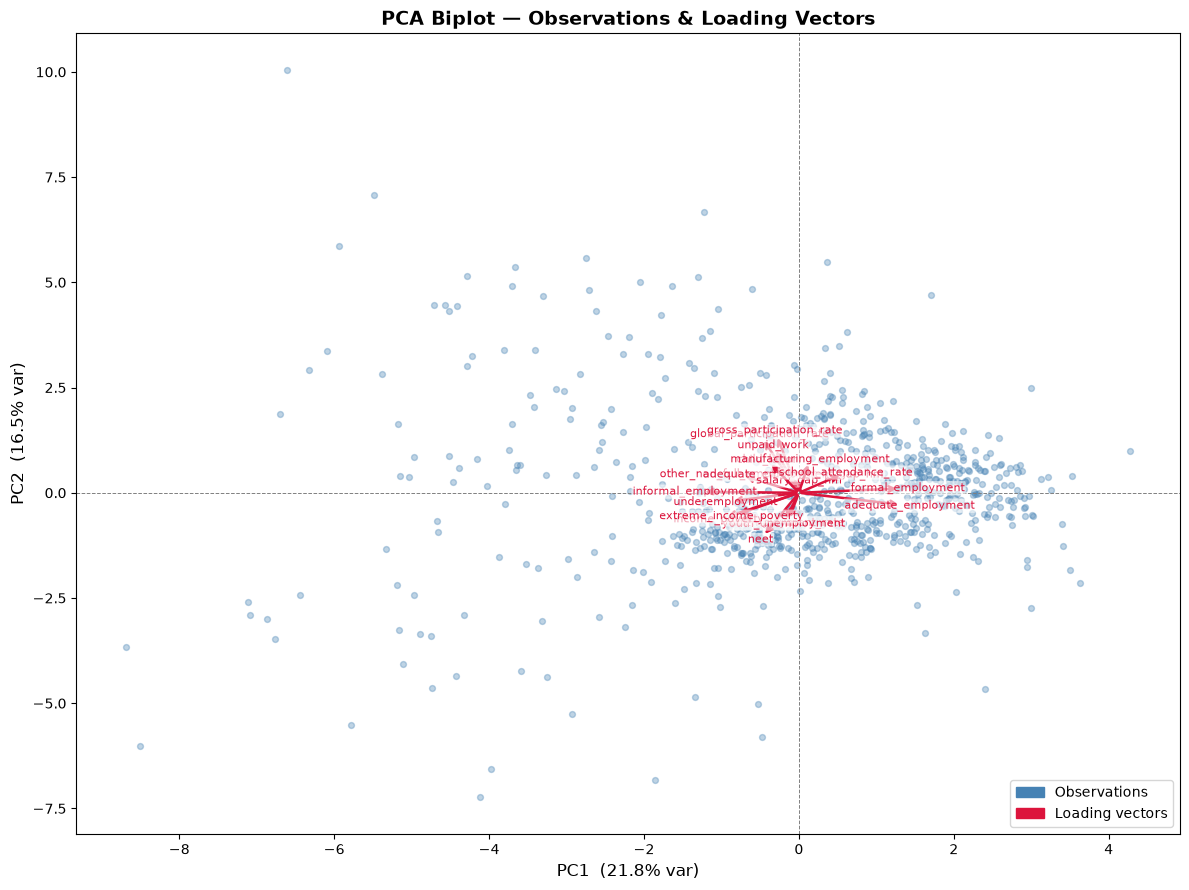

In [46]:
def plot_pca_biplot(pca, X_pca, X_scaled, feature_names, pc_x=0, pc_y=1,
                   scale_factor=3, figsize=(12, 9)):
    """
    Biplot: scatter of observations on PCs + loading vectors.

    Parameters
    ----------
    pca          : fitted PCA object
    X_pca        : transformed data (n_samples, n_components)
    X_scaled     : standardized original data (for coloring by density, optional)
    feature_names: list of original variable names
    pc_x, pc_y   : which PCs to plot (0-indexed)
    scale_factor : multiplier to stretch loading arrows for visibility
    """
    fig, ax = plt.subplots(figsize=figsize)

    # ── 1. Scatter of observations ────────────────────────────────────────────
    ax.scatter(X_pca[:, pc_x], X_pca[:, pc_y],
               alpha=0.35, s=18, color='steelblue', label='Observations')

    # ── 2. Loading vectors ────────────────────────────────────────────────────
    loadings = pca.components_  # shape: (n_components, n_features)

    for i, feature in enumerate(feature_names):
        vx = loadings[pc_x, i] * scale_factor
        vy = loadings[pc_y, i] * scale_factor

        ax.annotate(
            '', xy=(vx, vy), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8)
        )
        ax.text(vx * 1.08, vy * 1.08, feature,
                fontsize=8, color='crimson', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))

    # ── 3. Axis labels with explained variance ───────────────────────────────
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC{pc_x+1}  ({var[pc_x]*100:.1f}% var)', fontsize=12)
    ax.set_ylabel(f'PC{pc_y+1}  ({var[pc_y]*100:.1f}% var)', fontsize=12)
    ax.set_title('PCA Biplot — Observations & Loading Vectors', fontsize=14, fontweight='bold')

    # ── 4. Reference lines & legend ──────────────────────────────────────────
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.axvline(0, color='grey', lw=0.7, ls='--')

    obs_patch   = mpatches.Patch(color='steelblue', label='Observations')
    arrow_patch = mpatches.Patch(color='crimson',   label='Loading vectors')
    ax.legend(handles=[obs_patch, arrow_patch], loc='lower right')

    plt.tight_layout()
    plt.savefig('pca_biplot.png', dpi=150)
    plt.show()

feature_names = [c for c in df.columns if c not in new_id_cols]

plot_pca_biplot(pca, X_pca, X_scaled, feature_names,
                pc_x=0, pc_y=1,   # change to explore other component pairs
                scale_factor=3)

## Varianza

In [47]:
explained_variance = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'varianza_explicada': pca.explained_variance_ratio_,
    'varianza_acumulada': pca.explained_variance_ratio_.cumsum()
})

explained_variance

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.217809,0.217809
1,PC2,0.165427,0.383236
2,PC3,0.107491,0.490726
3,PC4,0.088067,0.578793
4,PC5,0.080842,0.659635
5,PC6,0.055976,0.715611
6,PC7,0.052621,0.768233
7,PC8,0.049192,0.817425
8,PC9,0.041638,0.859062
9,PC10,0.034896,0.893958


## Cargas para PC1

In [48]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(X.shape[1])],
    index=X.columns
)

loadings[['PC1']].sort_values('PC1')

,PC1
informal_employment,-0.415712
income_poverty,-0.318655
underemployment,-0.292998
extreme_income_poverty,-0.268360
other_non_full_employment,-0.241754
global_participation_rate,-0.156619
neet,-0.153462
child_labor,-0.126704
unpaid_work,-0.103466
gross_participation_rate,-0.095929


## Construir el Indice Compuesto Multivariado (ICM) solo con el PC1

 - 0 = peor ICM relativo observado
 - 100 = mejor ICM relativo observado

In [52]:
indice_compuesto_multivariado = X_pca[:, 0]

indice_df = df.loc[X.index, id_cols].copy()
indice_df['indice_compuesto_multivariado'] = indice_compuesto_multivariado

indice_min = indice_df['indice_compuesto_multivariado'].min()
indice_max = indice_df['indice_compuesto_multivariado'].max()

# Transformación min-max del indice
indice_df['indice_compuesto_multivariado_0_100'] = (
    (indice_df['indice_compuesto_multivariado'] - indice_min) / (indice_max - indice_min)
) * 100

indice_df

,year,period,month,area,city,indice_compuesto_multivariado,indice_compuesto_multivariado_0_100
0,2007,6,Junio,1,010150,1.197765,76.263097
1,2007,6,Junio,1,070150,-1.950585,51.959910
2,2007,6,Junio,1,090150,-0.771270,61.063448
3,2007,6,Junio,1,170150,1.199826,76.279002
4,2007,6,Junio,1,180150,0.977625,74.563756
...,...,...,...,...,...,...,...
830,2026,4,Abril,1,070150,-0.229175,65.248063
831,2026,4,Abril,1,090150,-0.304468,64.666849
832,2026,4,Abril,1,170150,1.941992,82.008032
833,2026,4,Abril,1,180150,0.023609,67.199389


## Series temporales del Indice Compuesto Multivariado

In [53]:
Unique_cities = len(df['city'].unique())

# sort first
indice_df = indice_df.sort_values(['city', 'year', 'month']).copy()

indice_df.head()

,year,period,month,area,city,indice_compuesto_multivariado,indice_compuesto_multivariado_0_100
10,2007,12,Diciembre,1,010150,1.822126,81.082752
0,2007,6,Junio,1,010150,1.197765,76.263097
5,2007,9,Septiembre,1,010150,1.321938,77.221627
37,2008,12,Diciembre,1,010150,2.276687,84.591663
24,2008,6,Junio,1,010150,1.639079,79.669746


In [54]:
indice_df['date'] = pd.to_datetime(df['year'].astype(str) + '/' + df['period'].astype(str), format='%Y/%m')
indice_df.head()

,year,period,month,area,city,indice_compuesto_multivariado,indice_compuesto_multivariado_0_100,date
10,2007,12,Diciembre,1,010150,1.822126,81.082752,2007-12-01
0,2007,6,Junio,1,010150,1.197765,76.263097,2007-06-01
5,2007,9,Septiembre,1,010150,1.321938,77.221627,2007-09-01
37,2008,12,Diciembre,1,010150,2.276687,84.591663,2008-12-01
24,2008,6,Junio,1,010150,1.639079,79.669746,2008-06-01


In [57]:
chart_ts = alt.Chart(indice_df).mark_line(point=True).encode(
    x=alt.X(
        'date:T',
        title='Year',
        scale=alt.Scale(nice=True),
        axis=alt.Axis(format='%Y/%m')
    ),
    y=alt.Y(
        'indice_compuesto_multivariado:Q', 
        title='Multivariate Composite Index (0-100)',
        axis=alt.Axis(format='.0f', labelExpr="datum.label + '%'")
    ),
    color=alt.Color(
        'city:N', 
        title='City',
        legend=alt.Legend(
            orient='bottom',        # places legend below the chart
            direction='horizontal', # labels flow left-to-right
            columns=Unique_cities,              # adjust to fit your number of cities
            titleAnchor='middle'    # centers the "City" title
        )
    ),
    tooltip=[
        alt.Tooltip('year:O', title='Year'),
        alt.Tooltip('period:O', title='Month'),
        alt.Tooltip('area:N'),
        alt.Tooltip('city:N'),
        alt.Tooltip('indice_compuesto_multivariado:Q', format='.2f', title='Index')
    ]
).properties(
    width=700,
    height=400,
    title='Evolution of the Multivariate Composite Index (MCI) over time'
)
chart_ts.show()
chart_ts.save("graficas/indice_ts.png")

alt.Chart(...)